In [13]:
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from country_config import *
from run_config import *
from utils import *

In [14]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))

population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]

data_path = Path("data")
exp_path = validation_path
input_path  = Path(exp_path) / "input"
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print(f"Data Path: {os.path.abspath(data_path)}")
print(f"Input Path: {os.path.abspath(input_path)}")
print(f"Output Path: {os.path.abspath(output_path)}")
print(f"Analysis Path: {os.path.abspath(analysis_path)}")
print(f"Population Scale: {population_scale_from_input_yml}")
print(f"Birth Rate: {birth_rate_from_config}")

Data Path: /work/tuv89272/Calibration_Pipeline_v6_NG-SE/data
Input Path: /work/tuv89272/Calibration_Pipeline_v6_NG-SE/validation_3_0.25_population_scale_one_pattern_15_replicates/input
Output Path: /work/tuv89272/Calibration_Pipeline_v6_NG-SE/validation_3_0.25_population_scale_one_pattern_15_replicates/output
Analysis Path: /work/tuv89272/Calibration_Pipeline_v6_NG-SE/validation_3_0.25_population_scale_one_pattern_15_replicates/analysis
Population Scale: 0.25
Birth Rate: 0.0362


In [15]:
prevalence_obs_pixel_df, meta = read_raster_to_df_like_masim(f"{data_path}/{country_code}_pfpr_{calibration_year}.asc")
prevalence_obs_pixel_df.head()
population_obs_pixel_df, meta = read_raster_to_df_like_masim(f"{data_path}/{country_code}_population_projected_{calibration_year}.asc")
population_obs_pixel_df.head()

Generated 6851 locations from 58156 total cells, 51305 cells with no data
Generated 6851 locations from 58156 total cells, 51305 cells with no data


,location_id,value
0,0,1545.00381
1,1,2970.40845
2,2,1638.50861
3,3,687.15159
4,4,2809.49320


In [16]:
mean_clinical_episodes_pixel = pd.read_csv(f"{analysis_path}/mean_clinical_episodes_pixel.csv")
mean_treatment_pixel = pd.read_csv(f"{analysis_path}/mean_treatment_pixel.csv")
mean_prevalence_2_to_10_pixel = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10_pixel.csv")
mean_prevalence_under_5_pixel = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5_pixel.csv")
mean_population_pixel = pd.read_csv(f"{analysis_path}/mean_population_pixel.csv")

print((mean_prevalence_2_to_10_pixel["mean"] == 0).sum())
print(mean_prevalence_2_to_10_pixel["mean"].isna().sum())

0
0


In [17]:
mean_prevalence_2_to_10_pixel_to_merge = mean_prevalence_2_to_10_pixel[["location_id", "mean"]].copy()
mean_prevalence_2_to_10_pixel_to_merge = mean_prevalence_2_to_10_pixel_to_merge.rename(columns={"mean": "pfpr_sim"})

mean_population_pixel_to_merge = mean_population_pixel[["location_id", "mean"]].copy()
mean_population_pixel_to_merge = mean_population_pixel_to_merge.rename(columns={"mean": "population_sim"})
mean_population_pixel_to_merge["population_sim"] = mean_population_pixel_to_merge["population_sim"] / population_scale_from_input_yml  # reverse the scaling applied to population in the simulations

prevalence_obs_pixel_df = prevalence_obs_pixel_df.rename(columns={"value": "pfpr_obs"})
population_obs_pixel_df = population_obs_pixel_df.rename(columns={"value": "population_obs"})

compare_pixel_data = prevalence_obs_pixel_df.merge(mean_prevalence_2_to_10_pixel_to_merge, on="location_id", how="left")
compare_pixel_data = compare_pixel_data.merge(population_obs_pixel_df, on="location_id", how="left")
compare_pixel_data = compare_pixel_data.merge(mean_population_pixel_to_merge, on="location_id", how="left")
compare_pixel_data['pfpr_sim'] = compare_pixel_data['pfpr_sim'] / 100  # convert pfpr_sim from percentage to proportion
compare_pixel_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_clinical_episodes_pixel.csv", index=False)

print((mean_prevalence_2_to_10_pixel_to_merge["pfpr_sim"] == 0).sum())
print(mean_prevalence_2_to_10_pixel_to_merge["pfpr_sim"].isna().sum())


0
0


In [18]:
compare_pixel_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_clinical_episodes_pixel.csv", index_col=0)
compare_pixel_data
compare_pixel_data_nan = compare_pixel_data[compare_pixel_data['pfpr_sim'].isna()]
compare_pixel_data_nan

,pfpr_obs,pfpr_sim,population_obs,population_sim
location_id,,,,


In [19]:
# Inputs
ref_asc = Path(f"{data_path}/{country_code}_pfpr_{calibration_year}.asc")                # reference grid
df = compare_pixel_data


# 1) Read reference raster (shape + header)
ref_raster, meta = read_raster_with_nodata(ref_asc)
valid_mask = np.isfinite(ref_raster)  # where reference has data (non-nodata)

# 2) Build output raster initialized as nodata (NaN in memory)
out_raster = np.full(ref_raster.shape, np.nan, dtype=float)

# 3) Fill valid cells in row-major order using location_id mapping
pfpr_sim = df.sort_index()["pfpr_sim"]

# Detect missing
n_nan = pfpr_sim.isna().sum()
if n_nan > 0:
    warn(f"Warning: {n_nan} NaN values in pfpr_sim")
    nan_lids = pfpr_sim[pfpr_sim.isna()].index
    
    # Locate spatially
    valid_indices = np.flatnonzero(valid_mask)
    nan_flat = valid_indices[nan_lids]
    nan_rows, nan_cols = np.unravel_index(nan_flat, ref_raster.shape)
    print(f"  Row range: {nan_rows.min()}–{nan_rows.max()}")
    print(f"  Col range: {nan_cols.min()}–{nan_cols.max()}")

    # Fill: use 0 (no transmission) or obs value (neutral for difference map)
    pfpr_sim = pfpr_sim.fillna(0)
    # pfpr_sim = pfpr_sim.fillna(df["pfpr_obs"])  # alternative

print(ref_raster.shape)
print(ref_raster.sum())
print(valid_mask.sum())

print(ref_raster)

out_raster[valid_mask] = pfpr_sim.to_numpy(dtype=float)


(217, 268)
nan
6851
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [20]:
print(len(df), valid_mask.sum())

6851 6851


In [21]:
# 4) Write raster with same georeference as reference
write_raster(
    out_raster,
    f"{analysis_path}/{country_code}_pfpr2to10_sim.asc",
    xllcorner=meta["xllcorner"],
    yllcorner=meta["yllcorner"],
    cellsize=int(meta["cellsize"]),
)

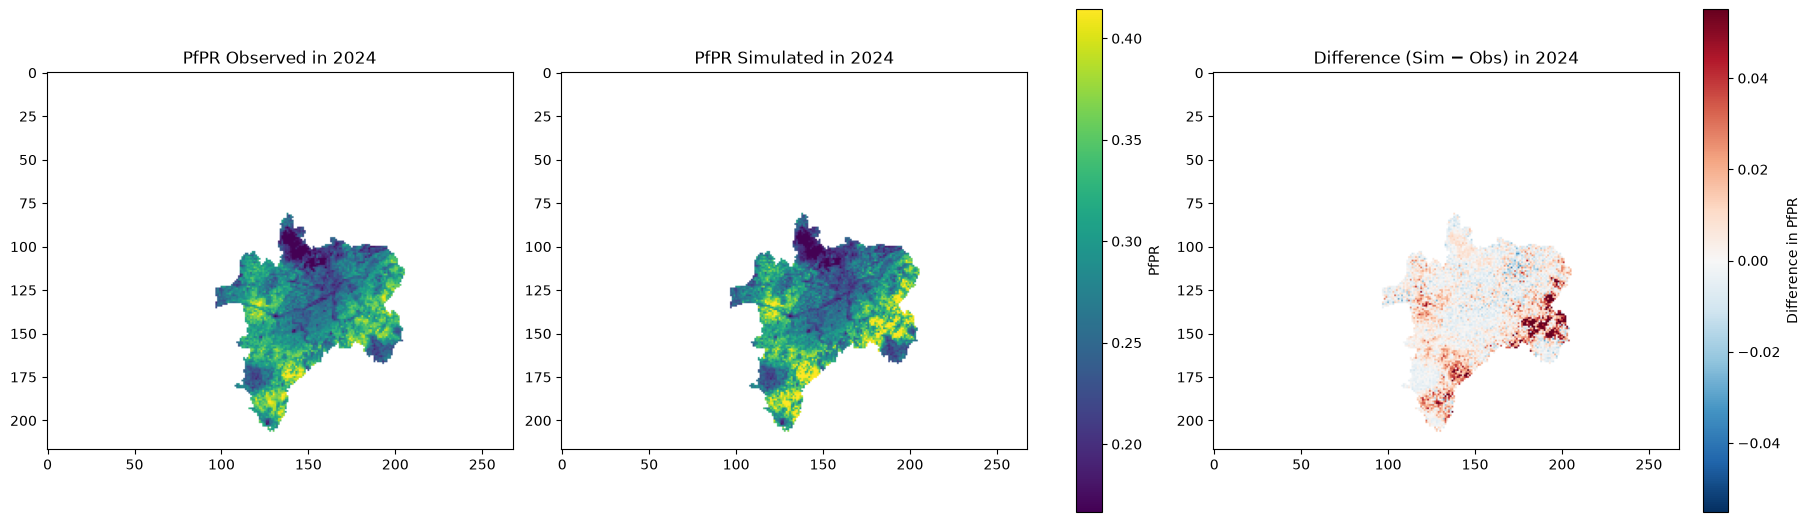

In [ ]:
# obs_path = Path(f"{data_path}/{country_code}_pfpr2to10.asc")
obs_path = Path(f"{data_path}/{country_code}_pfpr_{calibration_year}.asc")
sim_path = Path(f"{analysis_path}/{country_code}_pfpr2to10_sim.asc")

obs, _ = read_raster_with_nodata(obs_path)
sim, _ = read_raster_with_nodata(sim_path)

# Difference map (mask nodata where either is nodata)
diff = sim - obs
diff[~np.isfinite(obs) | ~np.isfinite(sim)] = np.nan

# Shared scale for obs/sim
vmin = np.nanpercentile(np.r_[obs[np.isfinite(obs)], sim[np.isfinite(sim)]], 2)
vmax = np.nanpercentile(np.r_[obs[np.isfinite(obs)], sim[np.isfinite(sim)]], 98)

# Symmetric scale for difference
dmax = np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 98)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im0 = axes[0].imshow(obs, vmin=vmin, vmax=vmax, cmap="viridis", zorder=2)
axes[0].set_title(f"PfPR Observed in {calibration_year}")
# axes[0].axis("off")

im1 = axes[1].imshow(sim, vmin=vmin, vmax=vmax, cmap="viridis", zorder=2)
axes[1].set_title(f"PfPR Simulated in {calibration_year}")
# axes[1].axis("off")

im2 = axes[2].imshow(diff, vmin=-dmax, vmax=dmax, cmap="RdBu_r", zorder=2)
axes[2].set_title(f"Difference (Sim − Obs) in {calibration_year}")
# axes[2].axis("off")

# Colorbars: one for obs/sim, one for diff
cbar1 = fig.colorbar(im1, ax=axes[:2], shrink=0.85)
cbar1.set_label("PfPR")

cbar2 = fig.colorbar(im2, ax=axes[2], shrink=0.85)
cbar2.set_label("Difference in PfPR")

plt.savefig(f"{analysis_path}/observed_vs_simulated_pfpr_{calibration_year}_pixel_maps.png", dpi=200)
plt.show()

In [40]:
# --- your functions: read_raster, write_raster (as you provided) ---

# Inputs
ref_asc = Path(f"{data_path}/{country_code}_population_projected_{calibration_year}.asc")                # reference grid
df = compare_pixel_data

# 1) Read reference raster (shape + header)
ref_raster, meta = read_raster_with_nodata(ref_asc)
valid_mask = np.isfinite(ref_raster)  # where reference has data (non-nodata)

# 2) Build output raster initialized as nodata (NaN in memory)
out_raster = np.full(ref_raster.shape, np.nan, dtype=float)

# 3) Fill valid cells in row-major order using location_id mapping
#    (this matches MaSim/C++ sequential location assignment)
pfpr_sim = df.sort_values("location_id")["population_sim"].to_numpy(dtype=float)

# Put pfpr_sim into the valid cells (NaNs stay NaN -> written as -9999)
out_raster[valid_mask] = pfpr_sim

# 4) Write raster with same georeference as reference
write_raster(
    out_raster,
    f"{analysis_path}/{country_code}_population_sim.asc",
    xllcorner=meta["xllcorner"],
    yllcorner=meta["yllcorner"],
    cellsize=int(meta["cellsize"]),
)

       ADM1_EN  ID_NUMBER
0        Benue          7
1  Cross River          9
2       Ebonyi         11
3    Nassarawa         26
4      Plateau         32
5       Taraba         35


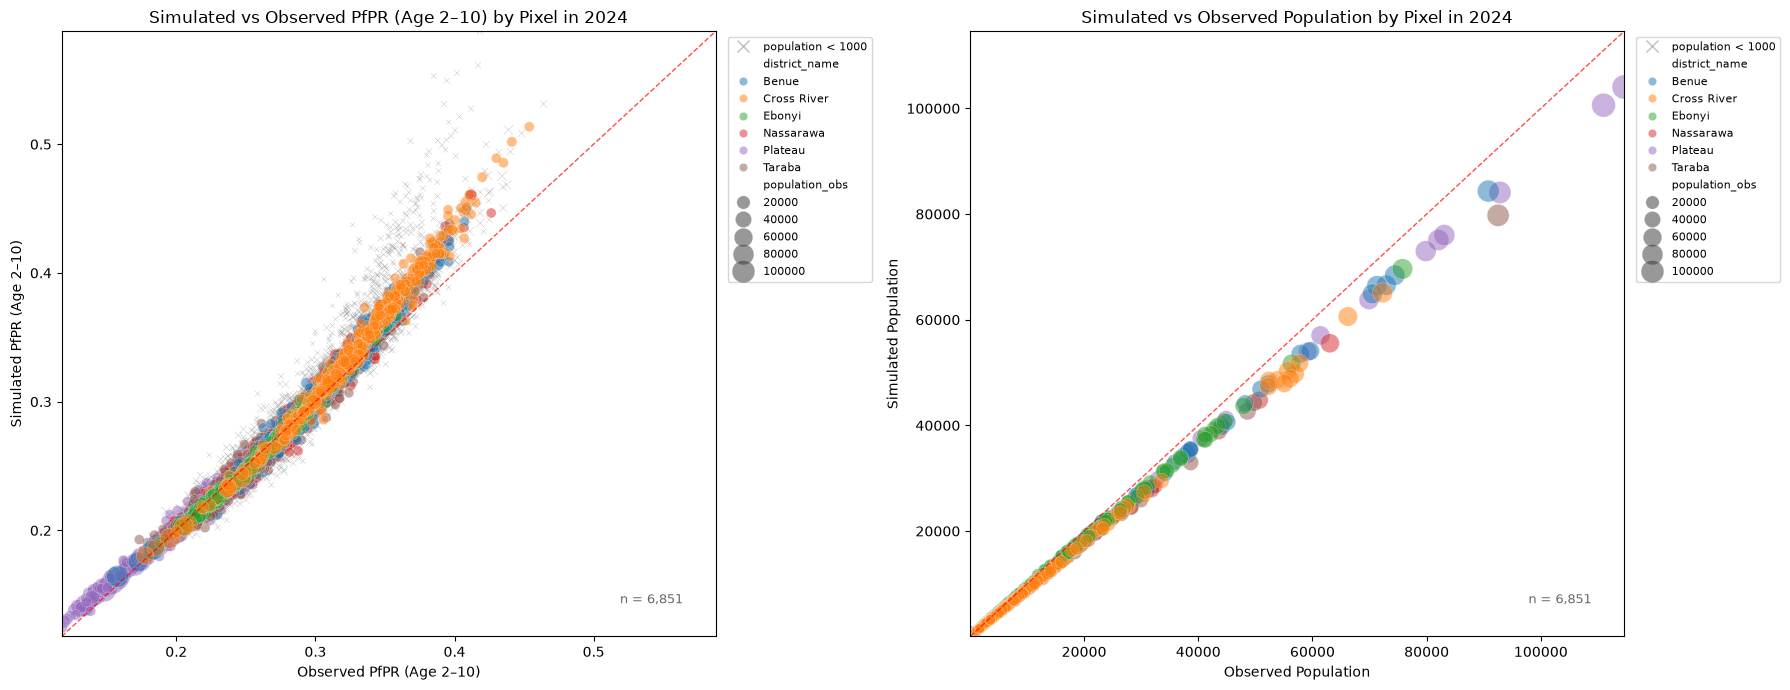

In [45]:
# -----------------------
# Load all rasters
# -----------------------
district_path  = Path(f"{data_path}/{country_code}_district.asc")
mapping_path   = Path(f"{data_path}/{country_code}_mapping.csv")
pfpr_obs_path  = Path(f"{data_path}/{country_code}_pfpr_{calibration_year}.asc")
pfpr_sim_path  = Path(f"{analysis_path}/{country_code}_pfpr2to10_sim.asc")
pop_obs_path   = Path(f"{data_path}/{country_code}_population_projected_{calibration_year}.asc")
pop_sim_path   = Path(f"{analysis_path}/{country_code}_population_sim.asc")

districts, _  = read_raster_with_nodata(district_path)
mapping       = pd.read_csv(mapping_path).iloc[:10, :]

print(mapping)
id_to_name    = mapping.set_index("ID_NUMBER")["ADM1_EN"].to_dict()

pfpr_obs, _   = read_raster_with_nodata(pfpr_obs_path)
pfpr_sim, _   = read_raster_with_nodata(pfpr_sim_path)
pop_obs, _    = read_raster_with_nodata(pop_obs_path)
pop_sim, _    = read_raster_with_nodata(pop_sim_path)

# -----------------------
# Build valid-pixel mask
# -----------------------
valid_mask = (
    np.isfinite(pfpr_obs) &
    np.isfinite(pfpr_sim) &
    np.isfinite(pop_obs) &
    np.isfinite(pop_sim)
).ravel()

# -----------------------
# Flatten and filter arrays
# -----------------------
district_flat  = districts.ravel()[valid_mask]
pfpr_obs_flat  = pfpr_obs.ravel()[valid_mask]
pfpr_sim_flat  = pfpr_sim.ravel()[valid_mask]
pop_obs_flat   = pop_obs.ravel()[valid_mask]
pop_sim_flat   = pop_sim.ravel()[valid_mask]

district_names = pd.Series(district_flat).map(id_to_name)

# -----------------------
# Assemble plot DataFrame
# -----------------------
plot_df = pd.DataFrame({
    "pfpr_obs":       pfpr_obs_flat,
    "pfpr_sim":       pfpr_sim_flat,
    "population_obs": pop_obs_flat,
    "population_sim": pop_sim_flat,
    "district_name":  district_names.values,
})

# Drop unknown district rows
plot_df = plot_df.dropna(subset=["district_name"])

# for min_population_bin in [100, 500, 1000]:
for min_population_bin in [1000]:


    # -----------------------
    # Split low / main by observed population
    # -----------------------

    df_low_pop = plot_df[plot_df["population_obs"] < min_population_bin].copy()
    df_main    = plot_df[plot_df["population_obs"] >= min_population_bin].copy()

    districts_ordered = mapping["ADM1_EN"].tolist()
    palette = sns.color_palette("tab10", n_colors=len(districts_ordered))

    # -----------------------
    # Plot
    # -----------------------
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))                                   # Plot horizontally
    # fig, ax = plt.subplots(2, 1, figsize=(9, 14), gridspec_kw={"hspace": 0.4})    # Plot vertically

    # =========================================
    # Left subplot: PfPR
    # =========================================
    sns.scatterplot(
        data=df_low_pop,
        x="pfpr_obs",
        y="pfpr_sim",
        size="population_obs",
        sizes=(5, 50),
        color="grey",
        marker="x",
        alpha=0.5,
        linewidth=0.3,
        legend=False,
        ax=ax[0]
    )

    sns.scatterplot(
        data=df_main,
        x="pfpr_obs",
        y="pfpr_sim",
        size="population_obs",
        sizes=(50, 300),
        alpha=0.5,
        hue="district_name",
        hue_order=districts_ordered,
        palette=palette,
        linewidth=0.3,
        legend="brief",
        ax=ax[0]
    )

    xmin_pfpr = min(plot_df["pfpr_obs"].min(), plot_df["pfpr_sim"].min())
    xmax_pfpr = max(plot_df["pfpr_obs"].max(), plot_df["pfpr_sim"].max())
    ax[0].plot([xmin_pfpr, xmax_pfpr], [xmin_pfpr, xmax_pfpr],
            linestyle="--", color="red", linewidth=1, alpha=0.7)

    ax[0].set_xlim(xmin_pfpr, xmax_pfpr)
    ax[0].set_ylim(xmin_pfpr, xmax_pfpr)
    ax[0].set_xlabel("Observed PfPR (Age 2–10)")
    ax[0].set_ylabel("Simulated PfPR (Age 2–10)")
    ax[0].set_title(f"Simulated vs Observed PfPR (Age 2–10) by Pixel in {calibration_year}")

    n_pfpr = len(df_main) + len(df_low_pop)
    ax[0].text(0.95, 0.05, f"n = {n_pfpr:,}", transform=ax[0].transAxes,
           ha="right", va="bottom", fontsize=9, color="dimgray")

    # custom legend for PfPR
    handles0, labels0 = ax[0].get_legend_handles_labels()
    low_pop_handle0 = Line2D(
        [0], [0],
        marker='x',
        color='w',
        label=f'population < {min_population_bin}',
        markerfacecolor='grey',
        markeredgecolor='grey',
        markersize=8,
        alpha=0.5
    )

    handles0 = [low_pop_handle0] + handles0
    labels0 = [f'population < {min_population_bin}'] + labels0

    unique_labels0 = []
    unique_handles0 = []
    for h, l in zip(handles0, labels0):
        if l not in unique_labels0:
            unique_labels0.append(l)
            unique_handles0.append(h)

    ax[0].legend(unique_handles0, unique_labels0,
                loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)

    # =========================================
    # Right subplot: Population
    # =========================================
    sns.scatterplot(
        data=df_low_pop,
        x="population_obs",
        y="population_sim",
        size="population_obs",
        sizes=(5, 50),
        color="grey",
        marker="x",
        alpha=0.5,
        linewidth=0.3,
        legend=False,
        ax=ax[1]
    )

    sns.scatterplot(
        data=df_main,
        x="population_obs",
        y="population_sim",
        size="population_obs",
        sizes=(50, 300),
        alpha=0.5,
        hue="district_name",
        hue_order=districts_ordered,
        palette=palette,
        linewidth=0.3,
        legend="brief",
        ax=ax[1]
    )

    xmin_pop = min(plot_df["population_obs"].min(), plot_df["population_sim"].min())
    xmax_pop = max(plot_df["population_obs"].max(), plot_df["population_sim"].max())
    ax[1].plot([xmin_pop, xmax_pop], [xmin_pop, xmax_pop],
            linestyle="--", color="red", linewidth=1, alpha=0.7)

    ax[1].set_xlim(xmin_pop, xmax_pop)
    ax[1].set_ylim(xmin_pop, xmax_pop)
    ax[1].set_xlabel("Observed Population")
    ax[1].set_ylabel("Simulated Population")
    ax[1].set_title(f"Simulated vs Observed Population by Pixel in {calibration_year}")

    n_population = len(df_main) + len(df_low_pop)
    ax[1].text(0.95, 0.05, f"n = {n_population:,}", transform=ax[1].transAxes,
           ha="right", va="bottom", fontsize=9, color="dimgray")

    # custom legend for Population
    handles1, labels1 = ax[1].get_legend_handles_labels()
    low_pop_handle1 = Line2D(
        [0], [0],
        marker='x',
        color='w',
        label=f'population < {min_population_bin}',
        markerfacecolor='grey',
        markeredgecolor='grey',
        markersize=8,
        alpha=0.5
    )

    handles1 = [low_pop_handle1] + handles1
    labels1 = [f'population < {min_population_bin}'] + labels1

    unique_labels1 = []
    unique_handles1 = []
    for h, l in zip(handles1, labels1):
        if l not in unique_labels1:
            unique_labels1.append(l)
            unique_handles1.append(h)

    ax[1].legend(unique_handles1, unique_labels1,
                loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_and_Population_{calibration_year}_{min_population_bin}.png",
                dpi=200, bbox_inches="tight")
    plt.show()

In [25]:
pfpr_obs
pfpr_sim
pop_obs
pop_sim

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(217, 268))

In [26]:
pop_thresholds = [20_000, 40_000, 60_000, 80_000]
df_pop_bins = {
    thresh: plot_df[plot_df["population_obs"] >= thresh].copy()
    for thresh in pop_thresholds
}
df_pop_bins


{20000:       pfpr_obs  pfpr_sim  population_obs  population_sim district_name
 46    0.197127   0.19657     21700.72554     19767.11111       Plateau
 58    0.177331   0.17919     59158.09794     53964.46667       Plateau
 59    0.195870   0.19529     38185.84006     34353.20000       Plateau
 70    0.160166   0.16447     26233.53404     23852.17778       Plateau
 72    0.173842   0.17636     92842.66020     84079.51111       Plateau
 ...        ...       ...             ...             ...           ...
 6821  0.322647   0.33022     23303.35440     20401.46667   Cross River
 6822  0.310646   0.31326     56065.91580     48895.37778   Cross River
 6823  0.177573   0.18034     52303.97830     47384.84444   Cross River
 6831  0.324540   0.33111     55074.32996     47932.13333   Cross River
 6832  0.299185   0.29977     33547.56684     29503.11111   Cross River
 
 [169 rows x 5 columns],
 40000:       pfpr_obs  pfpr_sim  population_obs  population_sim district_name
 58    0.177331   0.179

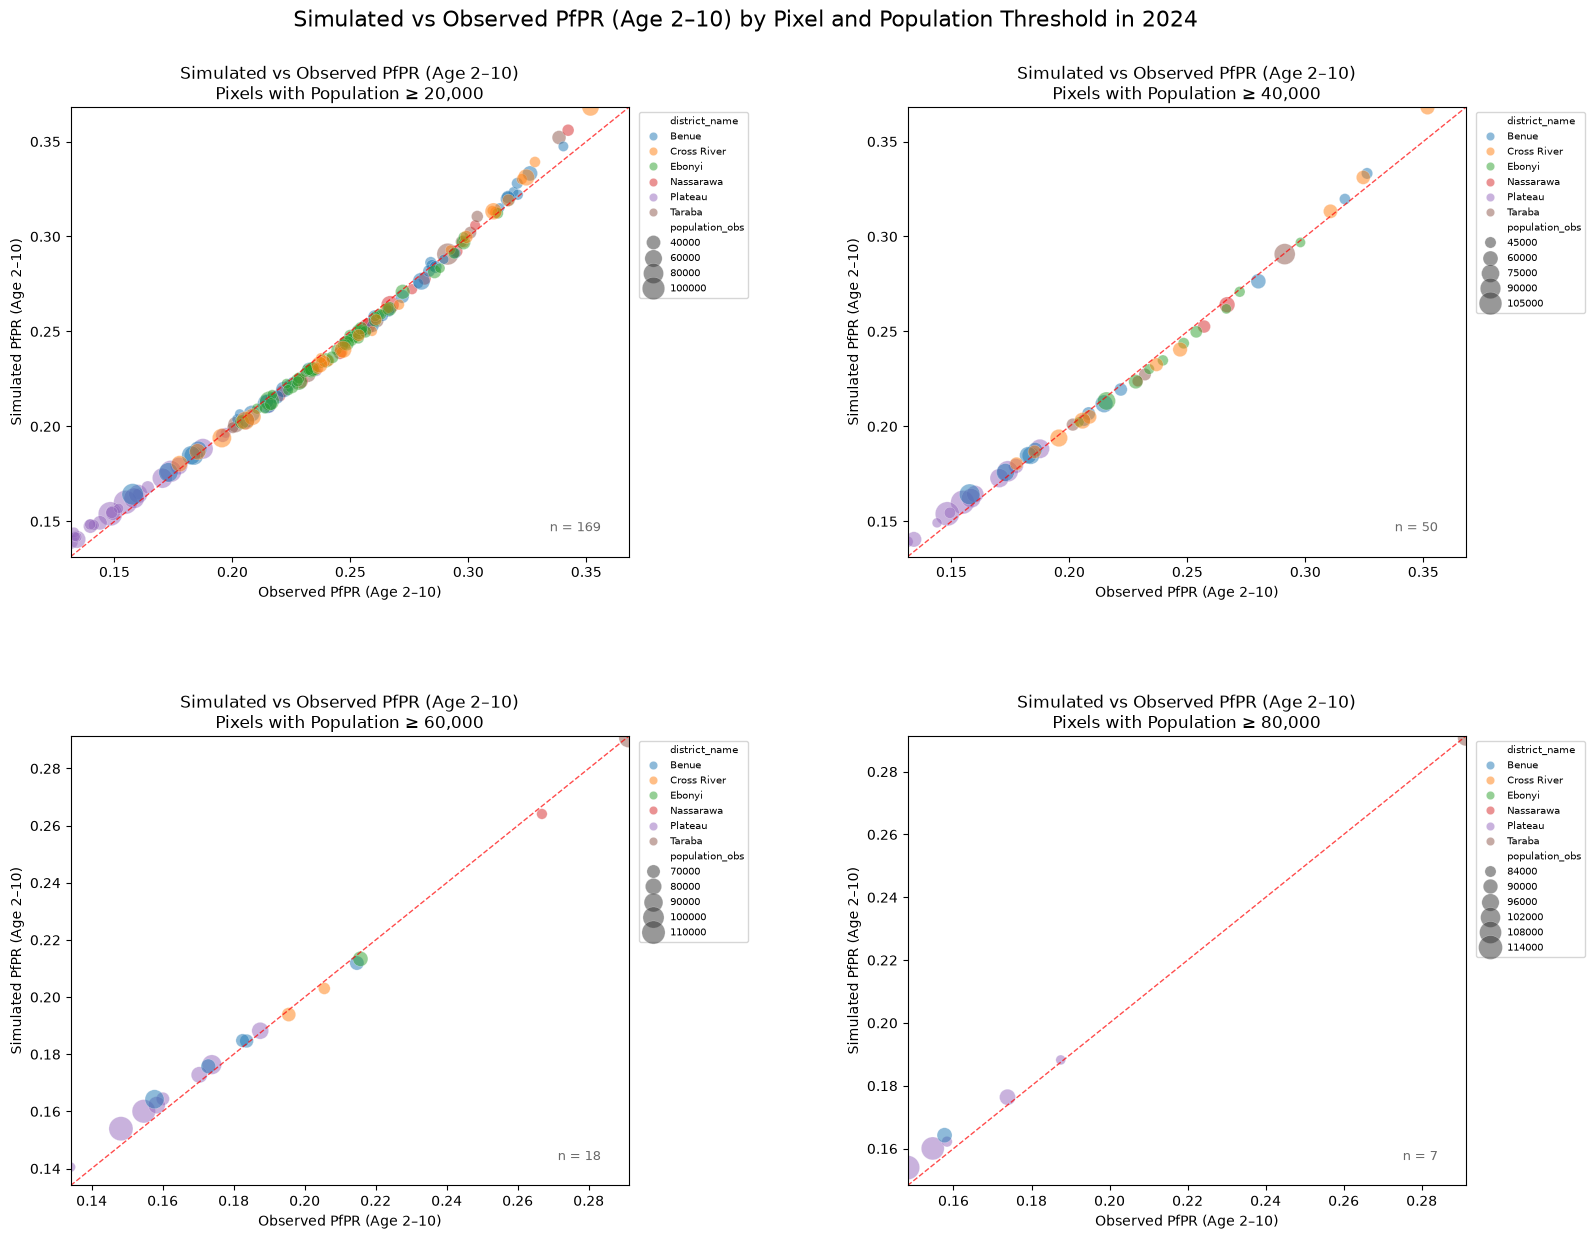

In [55]:
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 14), gridspec_kw={"hspace": 0.4, "wspace": 0.5})
axes2_flat = axes2.ravel()

fig2.suptitle(f"Simulated vs Observed PfPR (Age 2–10) by Pixel and Population Threshold in {calibration_year}", fontsize=16, y=0.95)

for i, thresh in enumerate(pop_thresholds):
    df_sub = df_pop_bins[thresh]
    a = axes2_flat[i]

    sns.scatterplot(
        data=df_sub,
        x="pfpr_obs",
        y="pfpr_sim",
        size="population_obs",
        sizes=(50, 300),
        alpha=0.5,
        hue="district_name",
        hue_order=districts_ordered,
        palette=palette,
        linewidth=0.3,
        legend="brief",
        ax=a
    )

    xmin = min(df_sub["pfpr_obs"].min(), df_sub["pfpr_sim"].min())
    xmax = max(df_sub["pfpr_obs"].max(), df_sub["pfpr_sim"].max())
    a.plot([xmin, xmax], [xmin, xmax], linestyle="--", color="red", linewidth=1, alpha=0.7)

    a.set_xlim(xmin, xmax)
    a.set_ylim(xmin, xmax)
    a.set_xlabel("Observed PfPR (Age 2\u201310)")
    a.set_ylabel("Simulated PfPR (Age 2\u201310)")
    a.set_title(f"Simulated vs Observed PfPR (Age 2–10)\nPixels with Population ≥ {thresh:,}")
    a.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7)

    n_count = len(df_sub)
    a.text(0.95, 0.05, f"n = {n_count:,}", transform=a.transAxes,
           ha="right", va="bottom", fontsize=9, color="dimgray")

plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_Population_Threshold_{calibration_year}_{min_population_bin}.png",
            dpi=200, bbox_inches="tight")
plt.show()

In [28]:
unique_districts = df_main["district_name"].unique()
df_by_district = {
    ud: plot_df[plot_df["district_name"] == ud].copy()
    for ud in unique_districts
}
df_by_district

{'Plateau':       pfpr_obs  pfpr_sim  population_obs  population_sim district_name
 0     0.281361   0.29126      1545.00381      1419.40000       Plateau
 1     0.254205   0.25219      2970.40845      2687.51111       Plateau
 2     0.215946   0.21330      1638.50861      1541.13333       Plateau
 3     0.282236   0.27013       687.15159       627.97778       Plateau
 4     0.249047   0.23662      2809.49320      2617.06667       Plateau
 ...        ...       ...             ...             ...           ...
 2345  0.230831   0.22399      1103.57415      1030.48889       Plateau
 2444  0.250350   0.24463      2462.65561      2268.51111       Plateau
 2445  0.210339   0.21001      3212.86858      2976.64444       Plateau
 2446  0.191407   0.19856      3084.57129      2775.33333       Plateau
 2447  0.217241   0.21023      1330.81257      1228.84444       Plateau
 
 [1066 rows x 5 columns],
 'Taraba':       pfpr_obs  pfpr_sim  population_obs  population_sim district_name
 237   0.247368

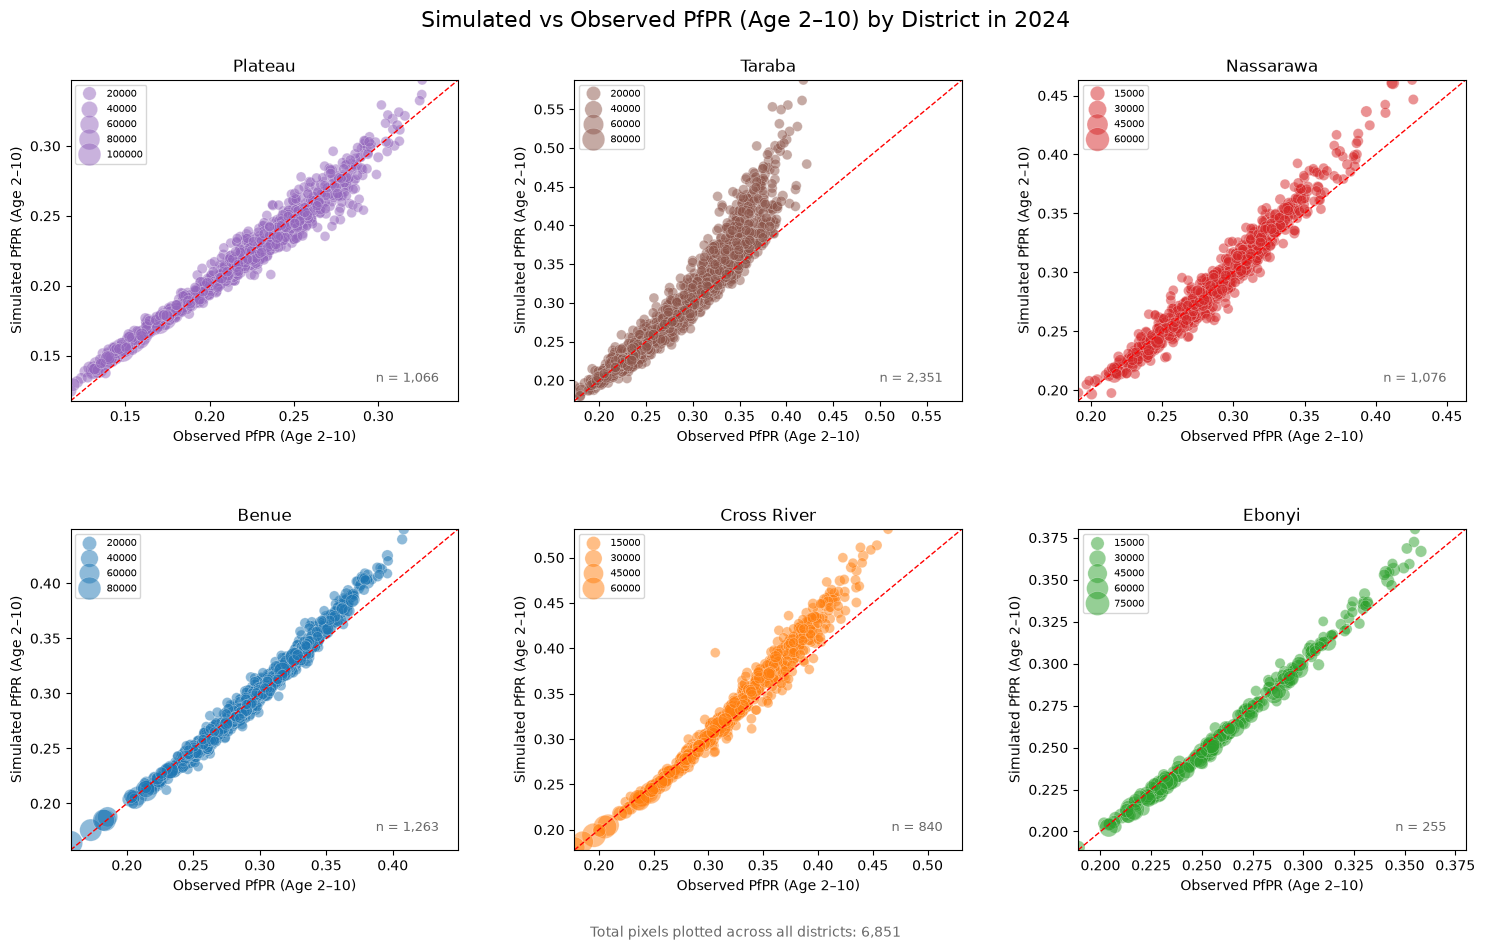

In [46]:
# -----------------------
# Plot per-district subplots
# -----------------------
n = len(unique_districts)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5), gridspec_kw={"hspace": 0.4, "wspace": 0.3})
axes_flat = axes.ravel()

fig.suptitle(f"Simulated vs Observed PfPR (Age 2–10) by District in {calibration_year}", fontsize=16, y=0.95)

sum_n = 0

for i, (district, df_sub) in enumerate(df_by_district.items()):
    a = axes_flat[i]

    sns.scatterplot(
        data=df_sub,
        x="pfpr_obs",
        y="pfpr_sim",
        size="population_obs",
        sizes=(50, 300),
        alpha=0.5,
        color=palette[districts_ordered.index(district)],
        linewidth=0.3,
        legend="brief",
        ax=a
    )

    xmin = min(df_sub["pfpr_obs"].min(), df_sub["pfpr_sim"].min())
    xmax = max(df_sub["pfpr_obs"].max(), df_sub["pfpr_sim"].max())
    a.plot([xmin, xmax], [xmin, xmax], linestyle="--", color="red", linewidth=1)

    a.set_xlim(xmin, xmax)
    a.set_ylim(xmin, xmax)
    a.set_xlabel("Observed PfPR (Age 2–10)")
    a.set_ylabel("Simulated PfPR (Age 2–10)")
    a.set_title(district)
    a.legend(loc="upper left", fontsize=7)

    n_count = len(df_sub)
    sum_n += n_count
    a.text(0.95, 0.05, f"n = {n_count:,}", transform=a.transAxes,
           ha="right", va="bottom", fontsize=9, color="dimgray")

# Hide any unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

# display sum of n across districts on plot
fig.text(0.5, 0.02, f"Total pixels plotted across all districts: {sum_n:,}",  color="dimgray", ha="center", va="bottom", fontsize=10)

plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()